### Importing Libraries

In [3]:
### import numpy as np
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import train_test_split

from itertools import combinations

from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import multivariate_normal


from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.utils import shuffle

###
### Data Prep

In [4]:
# --------  Reading Data -------

tmnst_df = pd.read_csv("tmnst Dataset.csv")

In [3]:
# ---- Checking some data records ------

tmnst_df.head(5)

,labels,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,D,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,F,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,J,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,H,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,A,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
# ------  Normalising Pixel values in range [0,1] instead of actual [0,255] -------------


# Separating Features and Lables
X = tmnst_df.drop(columns=['labels'])         # -- Features
y = tmnst_df['labels']                        # -- Labels

# Normalising the Features in range [0,1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Combining the normalised features with lables in a dataframe
normalized_tmnst_df = pd.DataFrame(X_scaled, 
                                 columns=X.columns,  
                                 index=X.index)
normalized_tmnst_df['labels'] = y


In [6]:
# ---- Checking some normalised data records ------

normalized_tmnst_df

,1,2,3,4,5,6,7,8,9,10,...,776,777,778,779,780,781,782,783,784,labels
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,D
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,F
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,J
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,H
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74719,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,U
74720,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,R
74721,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,N
74722,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,J


In [7]:
# ------  Splitting the data as Training and Test in 70/30 Ratio -----

train_df, test_df = train_test_split(
    normalized_tmnst_df,
    test_size=0.3,
    random_state=42,
    stratify=normalized_tmnst_df['labels']
)

###
### PROBLEM 1: Visualizing PCA vs. Fisher Scatter Plots

In [8]:
# ------  Defining the Function -----

def pca_vs_fisher_3d(train, selected_classes, label_col='labels'):
    if len(selected_classes) != 4:
        raise ValueError("Please provide exactly 4 class labels.")

    # Filter data for selected classes
    filtered_train = train[train[label_col].isin(selected_classes)].copy()
    
    X = filtered_train.drop(columns=[label_col]).values
    y = filtered_train[label_col].values

    style_map = {
    selected_classes[0]: {'color': 'red', 'marker': 'o'},      # circle
    selected_classes[1]: {'color': 'green', 'marker': 's'},    # square
    selected_classes[2]: {'color': 'blue', 'marker': '^'},     # triangle
    selected_classes[3]: {'color': 'cyan', 'marker': 'D'}      # diamond
    }
    
    
    # ---------- PART 1: PCA ----------
    pca = PCA(n_components=3)
    X_pca = pca.fit_transform(X)

    fig = plt.figure(figsize=(12, 5))
    ax1 = fig.add_subplot(121, projection='3d')

    for cls in selected_classes:
        idx = (y == cls)
        ax1.scatter(X_pca[idx, 0], X_pca[idx, 1], X_pca[idx, 2],
                    c=style_map[cls]['color'],
                    marker=style_map[cls]['marker'],
                    label=cls,
                    alpha=0.7)

    ax1.set_title("PCA Projection (3D)")
    ax1.set_xlabel("PC1")
    ax1.set_ylabel("PC2")
    ax1.set_zlabel("PC3")
    ax1.legend()

    # ---------- PART 2: Fisher (LDA) ----------
    lda = LDA(n_components=3)
    X_lda = lda.fit_transform(X, y)

    ax2 = fig.add_subplot(122, projection='3d')

    for cls in selected_classes:
        idx = (y == cls)
        ax2.scatter(X_lda[idx, 0], X_lda[idx, 1], X_lda[idx, 2],
                    c=style_map[cls]['color'],
                    marker=style_map[cls]['marker'],
                    label=cls,
                    alpha=0.7)

    ax2.set_title("Fisher Projection (3D)")
    ax2.set_xlabel("LD1")
    ax2.set_ylabel("LD2")
    ax2.set_zlabel("LD3")
    ax2.legend()

    plt.tight_layout()
    plt.show()

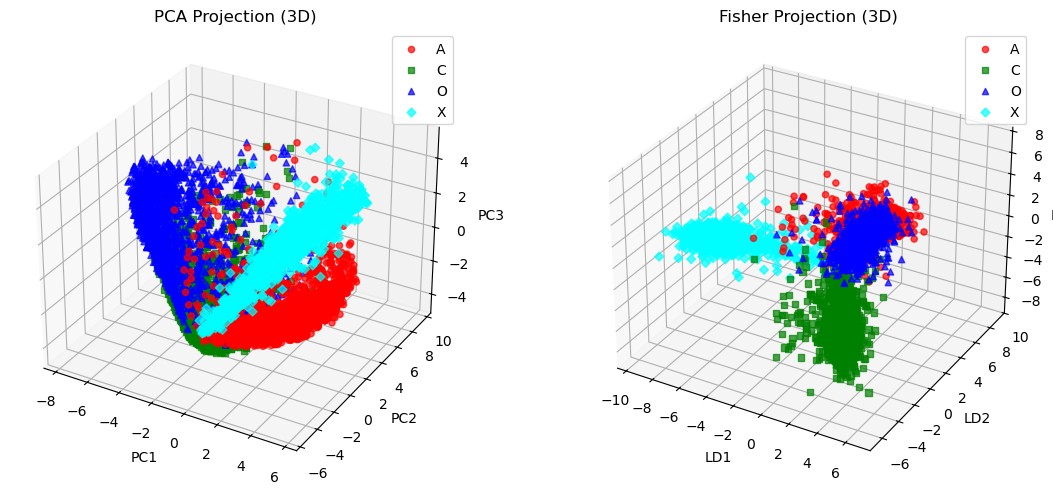

In [9]:
# ------  Calling the Function -----

pca_vs_fisher_3d(train_df, ['A', 'C', 'O', 'X'])

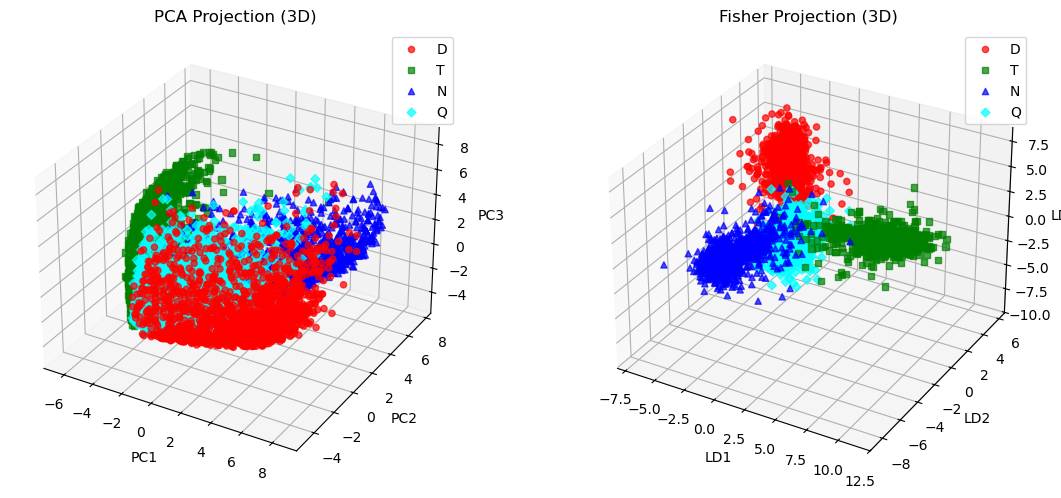

In [8]:
# ------  Calling the Function -----

pca_vs_fisher_3d(train_df, ['D', 'T', 'N', 'Q'])

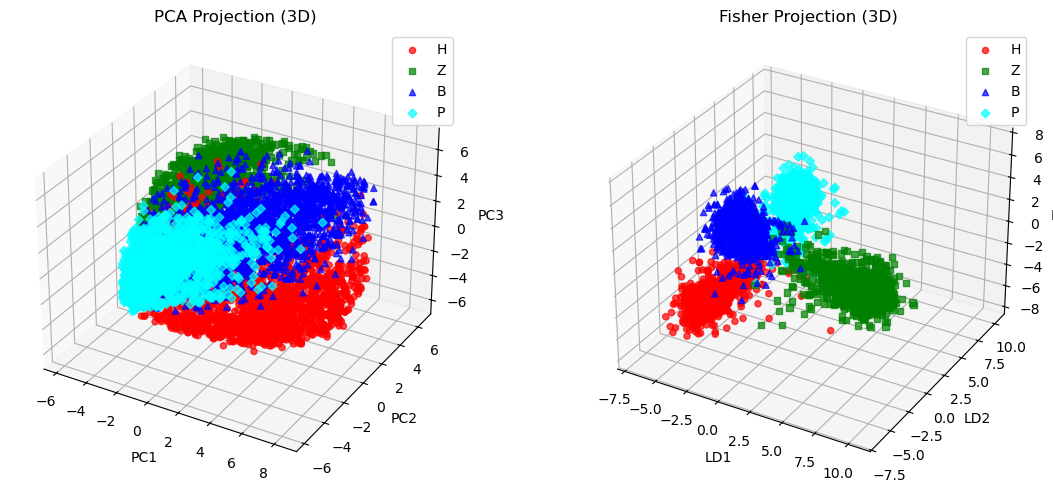

In [9]:
# ------  Calling the Function -----

pca_vs_fisher_3d(train_df, ['H', 'Z', 'B', 'P'])

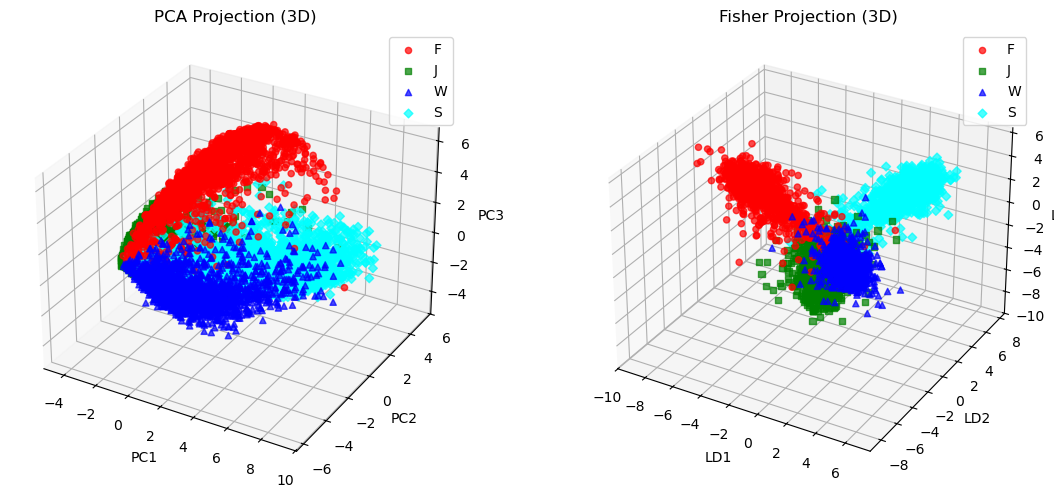

In [10]:
# ------  Calling the Function -----

pca_vs_fisher_3d(train_df, ['F', 'J', 'W', 'S'])

### Interpretation:
#### **Principal Component Analysis (PCA):**
- PCA projections are overlapped for all the four classes. It only creates the projections of data irrespective of what the labels are (ignoring the labels).
- PCA projects the data in a way to capture the maximum variance.
####
#### **Fischer Discrimant Analysis (FDA):**
- Fisher Projections are more clearly separable per class.
- We can see separate groups of data per class.
- Fisher maximises the between class separation while minimising the within class variance.

###
### PROBLEM 2: Visualizing all Classes via their Fisher Distance

In [10]:
# -------  Focusing on capital 26 letters --------

# Utilisng the training data 'train_df' created earlier

# Filtering the data for all Capital Letter classes A-Z
capital_letter_class = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")
capital_class_df = train_df[train_df['labels'].isin(capital_letter_class)]

In [11]:
# ------ Checking total unique classes -----

capital_class_df['labels'].nunique()

26

In [12]:
# ------  Part 1: Calculating Pairwise FISHER DISTANCE: Function definition -----

def compute_fisher_score_pairwise(X, y, epsilon=1e-6):
    X = np.asarray(X)
    y = np.asarray(y)
    unique_classes = sorted(np.unique(y))
    results = []

    for c1, c2 in combinations(unique_classes, 2):
        idx1 = y == c1
        idx2 = y == c2
        X1 = X[idx1]
        X2 = X[idx2]

        # Mean and variance per feature
        mean1 = np.mean(X1, axis=0)
        mean2 = np.mean(X2, axis=0)
        var1 = np.var(X1, axis=0)
        var2 = np.var(X2, axis=0)

        # Fisher score for each feature
        fisher_per_feature = (mean1 - mean2)**2 / (var1 + var2 + epsilon)
        avg_fisher = np.mean(fisher_per_feature)

        results.append((c1, c2, avg_fisher))

    return pd.DataFrame(results, columns=["class1", "class2", "fisher_score"])

In [13]:
# ------ Calling the function and showcase the fisher matrix -----------

X_capital = capital_class_df.drop(columns=['labels'])  
y_capital = capital_class_df['labels']

fisher_matrix_df = compute_fisher_score_pairwise(X_capital, y_capital)
fisher_matrix_df.to_csv("pairwise_fisher_scores.csv", index=False)

fisher_matrix_df

,class1,class2,fisher_score
0,A,B,0.279468
1,A,C,0.339383
2,A,D,0.340100
3,A,E,0.310999
4,A,F,0.308087
...,...,...,...
320,W,Y,0.448965
321,W,Z,0.461406
322,X,Y,0.322037
323,X,Z,0.230469


In [18]:
# ------  Part 2: CLASS VISUALIZATION USING t-SNE/MDS -----

from sklearn.manifold import MDS


def visualize_classes_with_mds(fisher_df, epsilon=1e-6):
    
    # All 26 unique class labels
    class_labels = sorted(set(fisher_df['class1']).union(fisher_df['class2']))
    n_classes = len(class_labels)

    # Create empty distance matrix
    distance_matrix = np.zeros((n_classes, n_classes))

    # Map class label to index
    label_to_index = {label: i for i, label in enumerate(class_labels)}

    # Fill upper triangle of matrix with distances
    for _, row in fisher_df.iterrows():
        i = label_to_index[row['class1']]
        j = label_to_index[row['class2']]
        fisher_val = row['fisher_score']
        distance = 1.0 / (fisher_val + epsilon)
        distance_matrix[i, j] = distance
        distance_matrix[j, i] = distance  # symmetric

    # Run MDS
    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
    points_2d = mds.fit_transform(distance_matrix)

    # Plot
    plt.figure(figsize=(6, 4))
    for i, label in enumerate(class_labels):
        x, y = points_2d[i]
        plt.scatter(x, y, s=100)
        plt.text(x + 0.01, y + 0.01, label, fontsize=12)
    
    plt.title("MDS Visualization of Class Similarity using Fisher Distance", fontsize=14)
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return points_2d


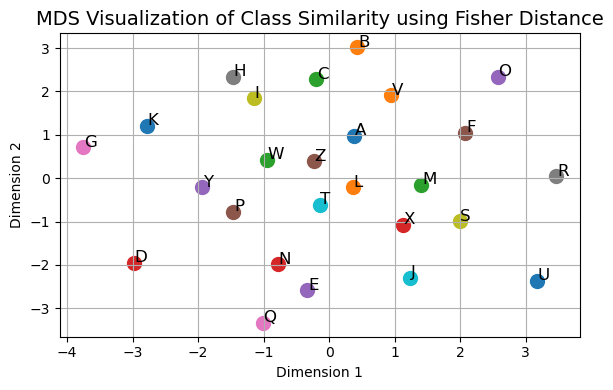

array([[ 0.38652607,  0.9778446 ],
       [ 0.43030686,  3.0238215 ],
       [-0.19818193,  2.28313424],
       [-2.98203909, -1.95375863],
       [-0.33205509, -2.58791336],
       [ 2.0804954 ,  1.04539634],
       [-3.75092595,  0.70832205],
       [-1.47393591,  2.34341059],
       [-1.14715145,  1.8432103 ],
       [ 1.24080479, -2.2969382 ],
       [-2.78142252,  1.2121855 ],
       [ 0.36052273, -0.21269579],
       [ 1.40895675, -0.15405036],
       [-0.77986413, -1.98125217],
       [ 2.57471144,  2.34131971],
       [-1.46102222, -0.77238878],
       [-1.01567069, -3.34036905],
       [ 3.46758455,  0.04392012],
       [ 1.99084917, -0.99491488],
       [-0.14518925, -0.60973758],
       [ 3.17661526, -2.36739055],
       [ 0.95114024,  1.91712152],
       [-0.94563418,  0.42198255],
       [ 1.12153602, -1.07187014],
       [-1.94233799, -0.2129241 ],
       [-0.23461888,  0.39453456]])

In [19]:
# -------- Visualize ----------

visualize_classes_with_mds(fisher_matrix_df)

### Interpretation:
#### 
- Fisher Score : Higher value indicates the two classes are more separable whereas a lower value inidcates classes are not very well separated.
- Basis the Fisher Distance i.e. 1 / (fisher value + epsilon), we can identify how closely two classes lie i.e. lower distance means classes are more near and higher value means classes are far away.
- Looking at the visualisation above, classes with higer distance are lying far away (such as GK, OR, etc)  and with lower distance are lying closer (such as WAZTL, HI etc).

###
### PROBLEM 3: KNN and Parzen Window classifiers hyper parameter sweeps

- **Projecting all the 26 classes in 25 Fisher Projections**

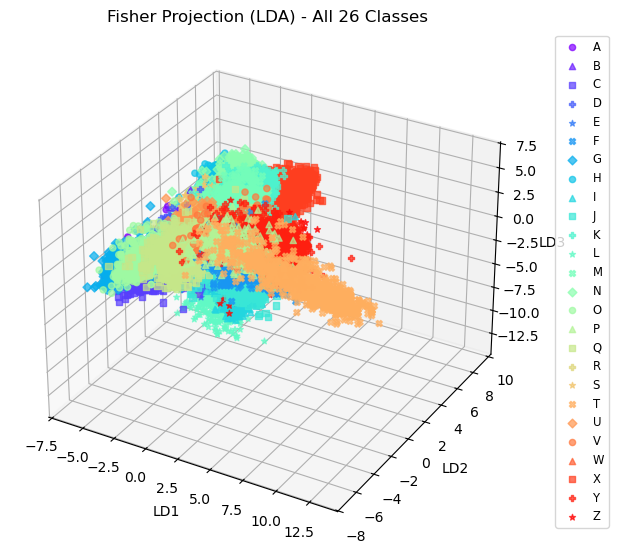

In [20]:
# ---------- Creating Feature Label on Training Data ----------

X_train = train_df.drop(columns=['labels'])
y_train = train_df['labels']
   

# STEP 1: Fisher Projections (LDA) on Training Data
lda_3 = LDA(n_components=25)  
X_lda_3 = lda_3.fit_transform(X_train, y_train)


# figure size for 3D plot
fig = plt.figure(figsize=(10, 6))
ax2 = fig.add_subplot(111, projection='3d')


# Automatically detect all 26 classes
all_classes = sorted(np.unique(y_train))


# defining color and marker for each class
import matplotlib.cm as cm
colors = cm.rainbow(np.linspace(0, 1, len(all_classes)))
markers = ['o', '^', 's', 'P', '*', 'X', 'D'] * 4  # Repeat to match 26


# Plot each class
for i, cls in enumerate(all_classes):
    idx = (y_train == cls)
    ax2.scatter(X_lda_3[idx, 0], X_lda_3[idx, 1], X_lda_3[idx, 2],
                c=[colors[i]],
                marker=markers[i % len(markers)],
                label=cls,
                alpha=0.7)

ax2.set_title("Fisher Projection (LDA) - All 26 Classes")
ax2.set_xlabel("LD1")
ax2.set_ylabel("LD2")
ax2.set_zlabel("LD3")
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

plt.tight_layout()
plt.show()

##### Interpretation:
- ABove graph shows all 26 classes projected in 3D Graph. Though we created the projections in 25D, visually we can only show it in 3D

In [21]:
# --------- Splitting Feature/Label for Training and Test data -------

# Training 
X_train = train_df.drop(columns=['labels'])
y_train = train_df['labels']

# Test
X_test = test_df.drop(columns=['labels'])
y_test = test_df['labels']
 
    
lda_3 = LDA(n_components=25)  

# STEP 1: Fisher Projections (LDA) on Training Data
X_train_lda = lda_3.fit_transform(X_train, y_train)


# Step 2: Fit LDA on Test data
X_test_lda = lda_3.transform(X_test)

In [36]:
# ------ Checking if there are any null values in the data -----------

test_df.isnull().values.any()

False

####
### KNN Parameter Sweep

In [22]:
# -----  KNN Parameter Sweep -----

k_values = [1,3,5,7,9,11,13,15,17]
knn_results = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_lda, y_train)
    
    train_acc = model.score(X_train_lda, y_train)
    test_acc = model.score(X_test_lda, y_test)
    
    knn_results.append((k, train_acc, test_acc))

# Save results
df_knn = pd.DataFrame(knn_results, columns=["k-value", "train-accuracy", "test-accuracy"])
df_knn.to_csv("Knn.csv", index=False)

In [23]:
df_knn.head(10)

,k-value,train-accuracy,test-accuracy
0,1,1.000000,0.947587
1,3,0.969296,0.944018
2,5,0.961075,0.943081
3,7,0.956544,0.940762
4,9,0.953619,0.939691
5,11,0.951841,0.938799
6,13,0.949451,0.937639
7,15,0.948113,0.936926
8,17,0.946488,0.936078


####
### Parzen Parameter Sweep

 **Taking a sample of training and test data to run Parzen function as function takes too long to exceute on entire dataset.**
 **Here, I have taken 50% of the data to run through Parzen**

In [24]:
# Taking a sample of Training and Test data for Parzen Sweep as code takes too much time on full training data

train_sample = train_df.sample(frac=0.5, random_state=42)
test_sample = test_df.sample(frac=0.5, random_state=42)

# Function was taking too long for 50% data, so did some runs on small dataset too.
# Finally I was able to run with the 50% of the data. All the further results are based on 50% of data 

#train_sample = train_df.sample(n=3000, random_state=42)  # tried 3000, 1500, 500
#test_sample = test_df.sample(n=3000, random_state=42)    # tried 3000, 1500, 500


# Training Feature and Label Split
X_train_parzen = train_sample.drop(columns=['labels'])
y_train_parzen = train_sample['labels']


# Test Feature and Label Split
X_test_parzen = test_sample.drop(columns=['labels'])
y_test_parzen = test_sample['labels']
 
    
lda_parzen = LDA(n_components=25)  

# STEP 1: Fisher Projections (LDA) on Training Data
X_train_lda_parzen = lda_parzen.fit_transform(X_train_parzen, y_train_parzen)


# Step 2: Fit LDA on Test data
X_test_lda_parzen = lda_parzen.transform(X_test_parzen)

In [25]:
# -----  Defining function for Parzen -----

'''
-- This definition was taking too long, hence defining a vectorised function below 

def parzen_predict(train_X, train_y, test_X, h):
    classes = np.unique(train_y)
    d = train_X.shape[1]
    preds = []

    for x in test_X:
        probs = {}
        for cls in classes:
            X_cls = train_X[train_y == cls]
            n = len(X_cls)
            density = 0
            for xi in X_cls:
                kernel = multivariate_normal(mean=xi, cov=h**2 * np.eye(d))
                density += kernel.pdf(x)
            probs[cls] = density / n
        preds.append(max(probs, key=probs.get))
    return np.array(preds)
'''


# ------ Vectorized Parzen Prediction Function ------
def parzen_predict_vectorized(train_X, train_y, test_X, h):
    classes = np.unique(train_y)
    d = train_X.shape[1]
    preds = []

    norm_const = 1 / ((2 * np.pi) ** (d / 2) * (h ** d))

    for x in test_X:
        probs = {}
        for cls in classes:
            X_cls = train_X[train_y == cls]
            dists_sq = np.sum((X_cls - x) ** 2, axis=1)
            kernel_vals = norm_const * np.exp(-dists_sq / (2 * h ** 2))
            probs[cls] = np.sum(kernel_vals) / len(X_cls)
        preds.append(max(probs, key=probs.get))

    return np.array(preds)

In [26]:
# -----  Parzen Parameter Sweep -----

'''
h_values = [0.1, 0.5, 1, 1.5, 2, 3, 4, 6, 8, 10]
parzen_results = []

for h in h_values:
    print(f"Running for h = {h}...")
    y_train_pred = parzen_predict(X_train_lda_parzen, y_train_parzen, X_train_lda_parzen, h)
    y_test_pred = parzen_predict(X_train_lda_parzen, y_train_parzen, X_test_lda_parzen, h)

    train_acc = accuracy_score(y_train_parzen, y_train_pred)
    test_acc = accuracy_score(y_test_parzen, y_test_pred)

    parzen_results.append((h, train_acc, test_acc))

# Save results
df_parzen = pd.DataFrame(parzen_results, columns=["sigma-value", "train-accuracy", "test-accuracy"])
'''

# ------- Trying vectorised Parzen for parameter sweep ------

h_values = [0.1, 0.5, 1, 1.5, 2, 3, 4, 6, 8, 10]
parzen_results = []

for h in h_values:
    print(f"Running for h = {h}...")
    y_train_pred = parzen_predict_vectorized(X_train_lda_parzen, y_train_parzen, X_train_lda_parzen, h)
    y_test_pred  = parzen_predict_vectorized(X_train_lda_parzen, y_train_parzen, X_test_lda_parzen, h)
    

    train_acc = accuracy_score(y_train_parzen, y_train_pred)
    test_acc  = accuracy_score(y_test_parzen, y_test_pred)

    parzen_results.append((h, train_acc, test_acc))

df_parzen = pd.DataFrame(parzen_results, columns=["sigma-value", "train-accuracy", "test-accuracy"])

Running for h = 0.1...
Running for h = 0.5...
Running for h = 1...
Running for h = 1.5...
Running for h = 2...
Running for h = 3...
Running for h = 4...
Running for h = 6...
Running for h = 8...
Running for h = 10...


In [27]:
df_parzen.head(10)


,sigma-value,train-accuracy,test-accuracy
0,0.1,1.000000,0.865644
1,0.5,1.000000,0.935677
2,1.0,0.998432,0.935677
3,1.5,0.985241,0.925952
4,2.0,0.954001,0.909894
5,3.0,0.909609,0.888393
6,4.0,0.897067,0.879472
7,6.0,0.890644,0.872246
8,8.0,0.888617,0.870104
9,10.0,0.887432,0.869212


In [28]:
# ---- Saving to CSV -----

df_parzen.to_csv("ParzenResults_Vectorized.csv", index=False)

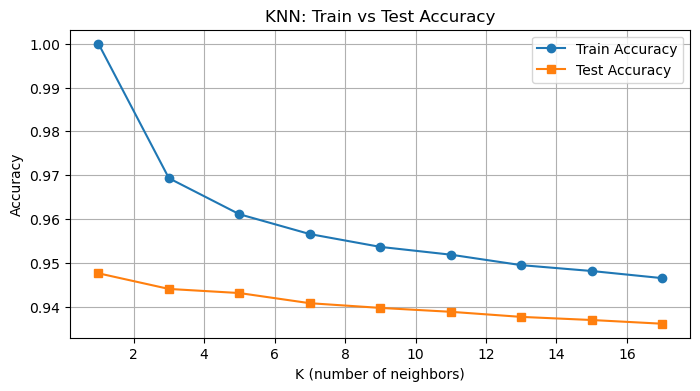

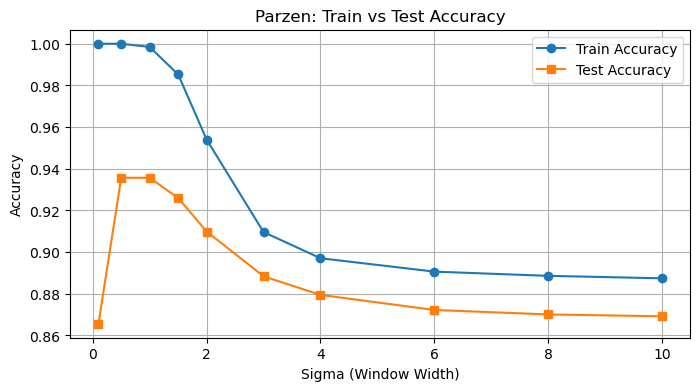

In [29]:
# ------ Visualising the accuracy for KNN and Parzen parameter Sweep ---

# Plot for KNN
plt.figure(figsize=(8, 4))
plt.plot(df_knn["k-value"], df_knn["train-accuracy"], label="Train Accuracy", marker='o')
plt.plot(df_knn["k-value"], df_knn["test-accuracy"], label="Test Accuracy", marker='s')
plt.title("KNN: Train vs Test Accuracy")
plt.xlabel("K (number of neighbors)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

# Plot for Parzen
plt.figure(figsize=(8, 4))
plt.plot(df_parzen["sigma-value"], df_parzen["train-accuracy"], label="Train Accuracy", marker='o')
plt.plot(df_parzen["sigma-value"], df_parzen["test-accuracy"], label="Test Accuracy", marker='s')
plt.title("Parzen: Train vs Test Accuracy")
plt.xlabel("Sigma (Window Width)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

####
#### Interpretation for KNN:
- When K is very small i.e. 1, the model memorises (overfits), thats why, we see perfect training accuracy but test accuracy drops. (High Variance Low Bias)
- When the K starts increasing, variance starts decreasing but bias increases, model underfits. For example K above 8
- The best K value could be somewhere between 3 to 6.
####
#### Interpretation of Parzen:
- When sigma is very low, model performs well on Training Data but underperforms on test data.
- When sigma is above 1, the test accuracy starts dropping.
- Sigma = 1 is the optimal value for generalised model.
- 

###
### PROBLEM 4: Perceptron vs. Logistic Regression

In [30]:
# ---- Converting Projections to dataframe ----

train_lda_df = pd.DataFrame(X_train_lda)
train_lda_df['labels'] = y_train.reset_index(drop=True)


test_lda_df = pd.DataFrame(X_test_lda)
test_lda_df['labels'] = y_test.reset_index(drop=True)

In [31]:
# ---- Perceptron Model ----

def perceptron_model(train, test, classes=['A', 'C']):
    results = []

    for run in range(1, 101):
        # Shuffle data
        train_shuffled = shuffle(train, random_state=run)
        test_shuffled = shuffle(test, random_state=run)

        # Filter selected classes
        train_filtered = train_shuffled[train_shuffled['labels'].isin(classes)]
        test_filtered = test_shuffled[test_shuffled['labels'].isin(classes)]

        # Prepare features and labels
        X_train = train_filtered.drop(columns=['labels']).to_numpy()
        y_train = train_filtered['labels'].map({classes[0]: 0, classes[1]: 1}).to_numpy()

        X_test = test_filtered.drop(columns=['labels']).to_numpy()
        y_test = test_filtered['labels'].map({classes[0]: 0, classes[1]: 1}).to_numpy()

        # Train model
        model = Perceptron(max_iter=1000, tol=1e-3)
        model.fit(X_train, y_train)

        # Accuracy
        train_acc = accuracy_score(y_train, model.predict(X_train))
        test_acc = accuracy_score(y_test, model.predict(X_test))

        results.append([run, train_acc, test_acc])

    # Save to CSV
    perceptron_df = pd.DataFrame(results, columns=["run", "train-accuracy", "test-accuracy"])
    filename = f"perceptron_{classes[0]}_{classes[1]}.csv"
    perceptron_df.to_csv(filename, index=False)
    
    return perceptron_df

In [33]:
# ---- Calling Perceptron Model on 25D Projections ----
classes = ['A','C']
perceptron_df = perceptron_model(train_lda_df, test_lda_df, classes=classes)

In [34]:
# ---- Logistic Model ----

def logistic_model(train, test, classes=['A', 'C']):
    results = []

    for run in range(1, 101):
        # Shuffle data
        train_shuffled = shuffle(train, random_state=run)
        test_shuffled = shuffle(test, random_state=run)

        # Filter selected classes
        train_filtered = train_shuffled[train_shuffled['labels'].isin(classes)]
        test_filtered = test_shuffled[test_shuffled['labels'].isin(classes)]

        # Prepare features and labels
        X_train = train_filtered.drop(columns=['labels']).to_numpy()
        y_train = train_filtered['labels'].map({classes[0]: 0, classes[1]: 1}).to_numpy()

        X_test = test_filtered.drop(columns=['labels']).to_numpy()
        y_test = test_filtered['labels'].map({classes[0]: 0, classes[1]: 1}).to_numpy()

        # Train model
        model = LogisticRegression(max_iter=1000)
        model.fit(X_train, y_train)

        # Accuracy
        train_acc = accuracy_score(y_train, model.predict(X_train))
        test_acc = accuracy_score(y_test, model.predict(X_test))

        results.append([run, train_acc, test_acc])

    # Save to CSV
    logistic_df = pd.DataFrame(results, columns=["run", "train-accuracy", "test-accuracy"])
    filename = f"logistic_{classes[0]}_{classes[1]}.csv"
    logistic_df.to_csv(filename, index=False)
    
    return logistic_df

In [35]:
# ---- Calling Logistic Model on 25D Projections ----
classes = ['A', 'C']
logistic_df = logistic_model(train_lda_df, test_lda_df, classes=classes)

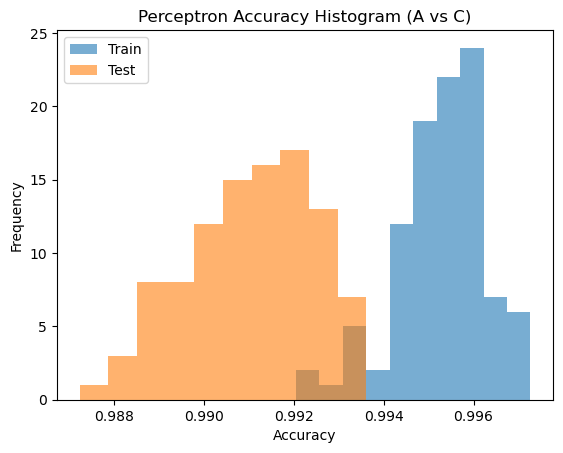

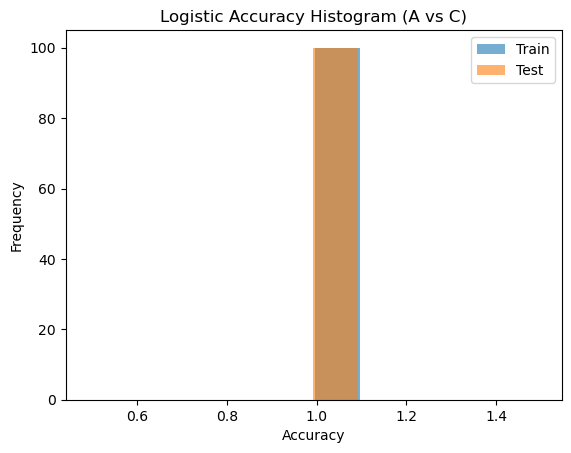

In [36]:
# -------- Plot Perceptron histogram ----

plt.hist(perceptron_df["train-accuracy"], bins=10, alpha=0.6, label="Train")
plt.hist(perceptron_df["test-accuracy"], bins=10, alpha=0.6, label="Test")
plt.title(f"Perceptron Accuracy Histogram ({classes[0]} vs {classes[1]})")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# -------- Plot Logistic histogram ----

plt.hist(logistic_df["train-accuracy"], bins=10, alpha=0.6, label="Train")
plt.hist(logistic_df["test-accuracy"], bins=10, alpha=0.6, label="Test")
plt.title(f"Logistic Accuracy Histogram ({classes[0]} vs {classes[1]})")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.legend()
plt.show()

####
#### Interpretation for Perceptron:
- Training Accuracy is higher compared to Test Accuracy across all runs
- There is not much overlap between Training and Test Accuracy
- Model is overfit as there is lot of gap between Training and Test Accuracy.
####
#### Interpretation of Logistic:
- Here, we can see that both Training and Test Accuracy overlaps over a single bar.
- This is more stable across all runs, accuracy is fixed over all runs.

In [37]:
# ----- Average Perceptron accuracy  -----

print(f"\nPerceptron Average Train Accuracy: {perceptron_df['train-accuracy'].mean():.4f}")
print(f"Perceptron Average Test Accuracy : {perceptron_df['test-accuracy'].mean():.4f}\n\n")

# ----- Average Logistics accuracy  -----

print(f"\nLogistic Average Train Accuracy: {logistic_df['train-accuracy'].mean():.4f}")
print(f"Logistic Average Test Accuracy : {logistic_df['test-accuracy'].mean():.4f}")


Perceptron Average Train Accuracy: 0.9952
Perceptron Average Test Accuracy : 0.9910



Logistic Average Train Accuracy: 0.9965
Logistic Average Test Accuracy : 0.9919


####
#### Interpretation for Perceptron And Logistic Avg Accuracy:
- Both model performs very well on average with very minimal gap in Training and Test Accuracy